In [76]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

In [53]:
df.head(500)
df[df['day'] == 'Thur']

,total_bill,tip,sex,smoker,day,time,size
77,27.20,4.00,Male,No,Thur,Lunch,4
78,22.76,3.00,Male,No,Thur,Lunch,2
79,17.29,2.71,Male,No,Thur,Lunch,2
80,19.44,3.00,Male,Yes,Thur,Lunch,2
81,16.66,3.40,Male,No,Thur,Lunch,2
...,...,...,...,...,...,...,...
202,13.00,2.00,Female,Yes,Thur,Lunch,2
203,16.40,2.50,Female,Yes,Thur,Lunch,2
204,20.53,4.00,Male,Yes,Thur,Lunch,4
205,16.47,3.23,Female,Yes,Thur,Lunch,3


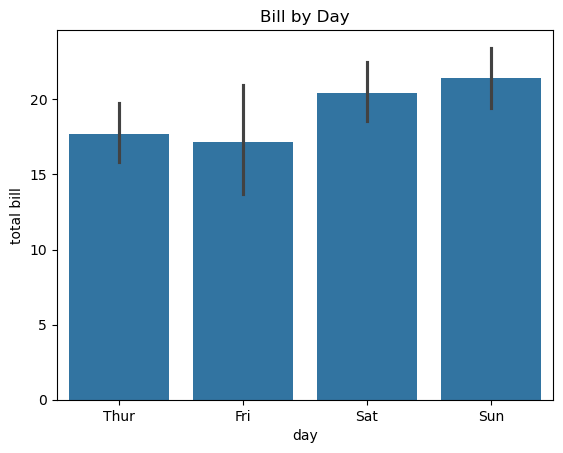

In [21]:
#task 1
sns.barplot(data=df, x='day', y='total_bill')
plt.title("Bill by Day")
plt.ylabel("total bill")
plt.show()

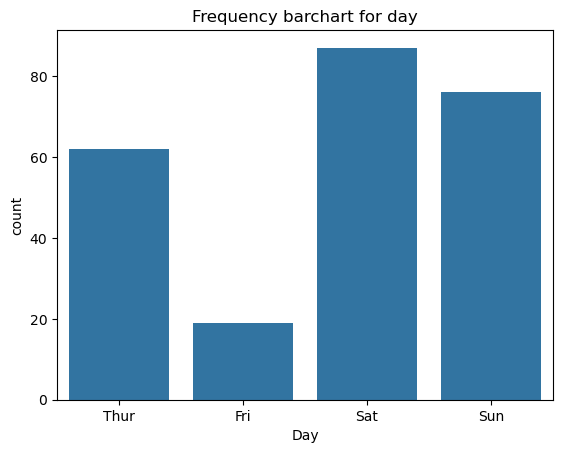

In [24]:
#task 2
sns.countplot(data=df, x='day')
plt.title("Frequency barchart for day")
plt.xlabel("Day")
plt.show()

"Saturday is the most common meaning most of the data is for Saturday so most orders were placed on Saturdays"

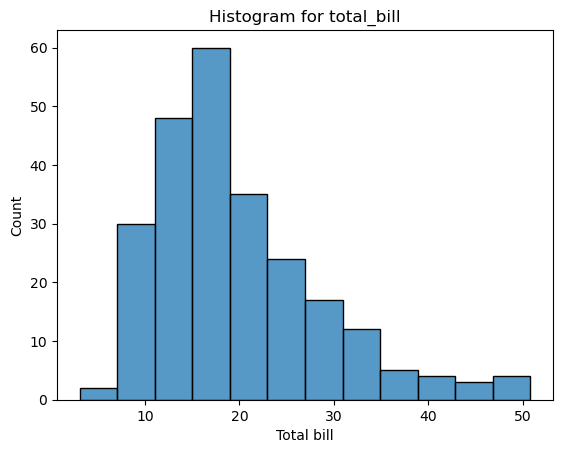

'skewed right as the tail is to the right'

In [60]:
#task 3
sns.histplot(data=df, x='total_bill', bins=12)
plt.title("Histogram for total_bill")
plt.xlabel("Total bill")
plt.ylabel("Count")
plt.show()


"skewed right as the tail is to the right"

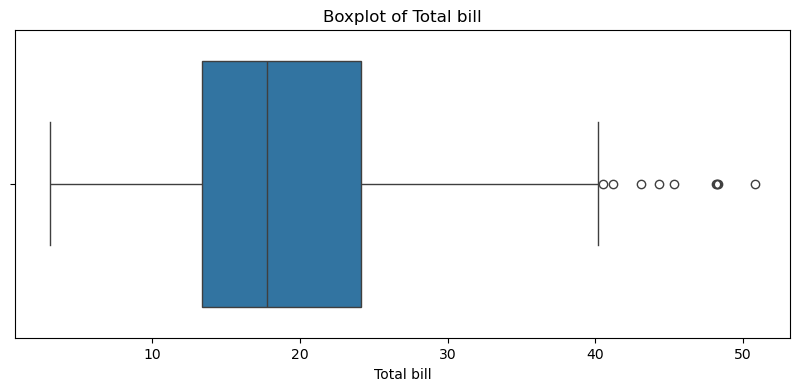

In [36]:
#task 4
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='total_bill')
plt.title("Boxplot of Total bill")
plt.xlabel("Total bill")
plt.show()


In [78]:
#task 5
Q1 = df["total_bill"].quantile(0.25)
Q3 = df["total_bill"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)


outliers = df[(df["total_bill"] < lower) | (df["total_bill"] > upper)]
print(len(outliers))


"Outliers are outside the whiskers and there are a lot less than compared to what IRQ method highlighted"

9


'Outliers are outside the whiskers and there are a lot less than compared to what IRQ method highlighted'

In [61]:
#task 6
from scipy import stats
df['zscore'] = stats.zscore(df["total_bill"])
outliers_z = df[df['zscore'].abs() > 3]
print(len(outliers_z))

"""Outliers are a lot less than IQR method 
The data is skewed towards the right and since IQR method just checks if value is not between Q1 and Q3 it flags a lot of values as outliers
Z-score assumes symmetry around the mean but since data is skewed it means the standard deviation is inflated so Z-score ends up hiding the outliers instead"""


4


Text(0, 0.5, 'Tip')

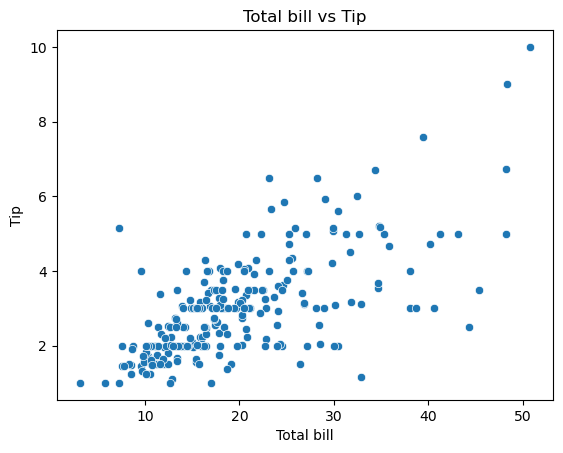

In [66]:
#task 7
sns.scatterplot(data=df, x="total_bill", y="tip")
plt.title("Total bill vs Tip")
plt.xlabel("Total bill")
plt.ylabel("Tip")

"yes as the total bill increases the tips do as well so its a positive relationship"

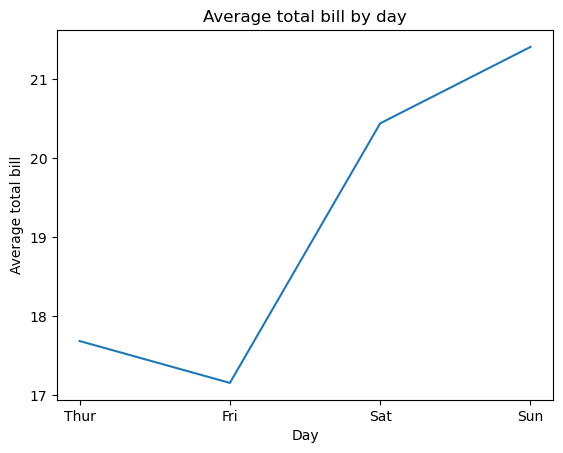

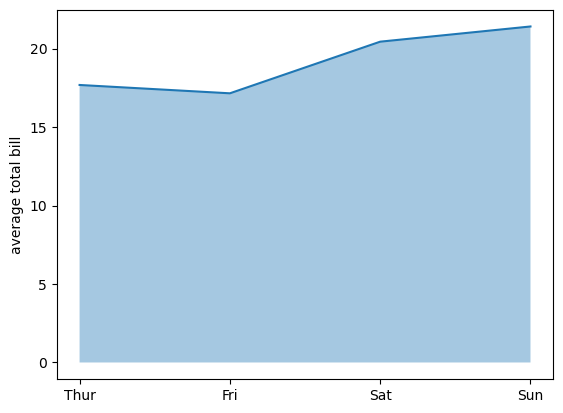

In [73]:
#task 8

sns.lineplot(data=df, x='day', y='total_bill', errorbar=None)
plt.title("Average total bill by day")
plt.ylabel('Average total bill')
plt.xlabel("Day")
plt.show()


avg_bill = df.groupby('day', observed=False)['total_bill'].mean()
plt.fill_between(avg_bill.index, avg_bill.values, alpha=0.4)
plt.plot(avg_bill.index, avg_bill.values)
plt.ylabel('average total bill')
plt.show()


"""The filled area shows the increase properly while line just shows points plotted against each other like x vs y
You cant properly tell how large the value for that point is"""

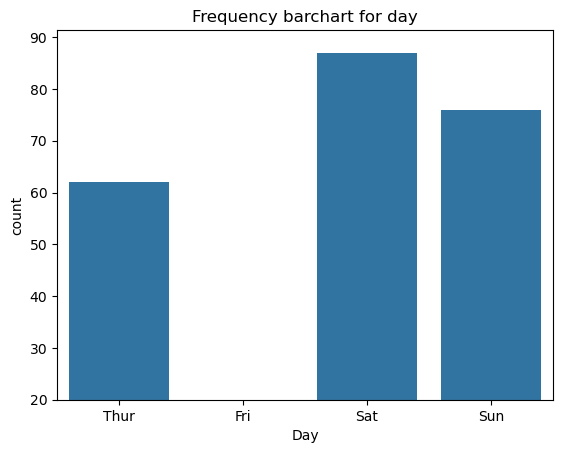

In [75]:
#task 9

sns.countplot(data=df, x='day')
plt.title("Frequency barchart for day")
plt.xlabel("Day")
plt.ylim(bottom=20)
plt.show()

"""I set the bottom to be 20 instead of 0 (task 2 had started from 0)
At first glance it looks like Friday has no orders at all, but in reality the current (bad) frequency boxplot shows that its just under 20"""
